# Breast Cancer Wisconsin — Load & Inspect

Loading and eyeballing the dataset only. No models, no experiments.

The data ships inside scikit-learn, so there is nothing to download and nothing
to put in `data/`.

**What it is:** 569 digitised images of a fine needle aspirate of a breast mass.
Each row is one patient. The 30 columns are measurements computed from the cell
nuclei visible in that image. The label says whether the mass was malignant or
benign.


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data            # inputs   (569, 30)
y = data.target          # targets  (569,)

print("inputs  X :", X.shape, X.dtype)
print("targets y :", y.shape, y.dtype)

inputs  X : (569, 30) float64
targets y : (569,) int64


## 1. The classes

Note the encoding — it is the opposite of what most people assume.

In [2]:
print("class names :", list(data.target_names))
print()
for i, name in enumerate(data.target_names):
    n = int((y == i).sum())
    print(f"  y == {i}  ->  {name:10s}  {n:3d} samples  ({n/len(y):.1%})")

print()
print("Careful: 0 = malignant, 1 = benign. The 'positive' class (1) is the healthy one.")
print(f"Slight imbalance: {(y==1).sum()} benign vs {(y==0).sum()} malignant.")

class names : [np.str_('malignant'), np.str_('benign')]

  y == 0  ->  malignant   212 samples  (37.3%)
  y == 1  ->  benign      357 samples  (62.7%)

Careful: 0 = malignant, 1 = benign. The 'positive' class (1) is the healthy one.
Slight imbalance: 357 benign vs 212 malignant.


## 2. The 30 features

They are not 30 independent measurements. There are **10 base measurements**,
each reported three ways: the `mean` over the nuclei in the image, the
`standard error`, and the `worst` (mean of the three largest values).

So the real structure is 10 x 3.

In [3]:
feat = list(data.feature_names)
print(f"{len(feat)} features\n")

base = [f.replace("mean ", "") for f in feat[:10]]
print(f"{'base measurement':<22}{'mean':<10}{'std error':<12}{'worst':<10}")
print("-" * 54)
for i, b in enumerate(base):
    print(f"{b:<22}{'col '+str(i):<10}{'col '+str(i+10):<12}{'col '+str(i+20):<10}")

30 features

base measurement      mean      std error   worst     
------------------------------------------------------
radius                col 0     col 10      col 20    
texture               col 1     col 11      col 21    
perimeter             col 2     col 12      col 22    
area                  col 3     col 13      col 23    
smoothness            col 4     col 14      col 24    
compactness           col 5     col 15      col 25    
concavity             col 6     col 16      col 26    
concave points        col 7     col 17      col 27    
symmetry              col 8     col 18      col 28    
fractal dimension     col 9     col 19      col 29    


## 3. Example rows — inputs and targets together

The 10 `mean` columns only, so the table stays readable.

In [4]:
df = pd.DataFrame(X, columns=feat)
df["target"] = y
df["class"]  = [data.target_names[i] for i in y]

df[feat[:10] + ["target", "class"]].head(8).round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,target,class
0,17.99,10.38,122.80,1001.0,0.118,0.278,0.300,0.147,0.242,0.079,0,malignant
1,20.57,17.77,132.90,1326.0,0.085,0.079,0.087,0.070,0.181,0.057,0,malignant
2,19.69,21.25,130.00,1203.0,0.110,0.160,0.197,0.128,0.207,0.060,0,malignant
3,11.42,20.38,77.58,386.1,0.142,0.284,0.241,0.105,0.260,0.097,0,malignant
4,20.29,14.34,135.10,1297.0,0.100,0.133,0.198,0.104,0.181,0.059,0,malignant
5,12.45,15.70,82.57,477.1,0.128,0.170,0.158,0.081,0.209,0.076,0,malignant
6,18.25,19.98,119.60,1040.0,0.095,0.109,0.113,0.074,0.179,0.057,0,malignant
7,13.71,20.83,90.20,577.9,0.119,0.164,0.094,0.060,0.220,0.075,0,malignant


## 4. A few individual samples in full

All 30 numbers for one patient, so you can see what a single input vector
actually looks like going into a model.

In [5]:
for idx in [0, 1, 20]:
    print("=" * 62)
    print(f"sample {idx}   target = {y[idx]}  ({data.target_names[y[idx]]})")
    print("=" * 62)
    for group, off in [("mean", 0), ("std error", 10), ("worst", 20)]:
        vals = "  ".join(f"{X[idx, off+j]:8.3f}" for j in range(10))
        print(f"  {group:<10} {vals}")
    print()

sample 0   target = 0  (malignant)
  mean         17.990    10.380   122.800  1001.000     0.118     0.278     0.300     0.147     0.242     0.079
  std error     1.095     0.905     8.589   153.400     0.006     0.049     0.054     0.016     0.030     0.006
  worst        25.380    17.330   184.600  2019.000     0.162     0.666     0.712     0.265     0.460     0.119

sample 1   target = 0  (malignant)
  mean         20.570    17.770   132.900  1326.000     0.085     0.079     0.087     0.070     0.181     0.057
  std error     0.543     0.734     3.398    74.080     0.005     0.013     0.019     0.013     0.014     0.004
  worst        24.990    23.410   158.800  1956.000     0.124     0.187     0.242     0.186     0.275     0.089

sample 20   target = 1  (benign)
  mean         13.080    15.710    85.630   520.000     0.107     0.127     0.046     0.031     0.197     0.068
  std error     0.185     0.748     1.383    14.670     0.004     0.019     0.017     0.006     0.017     0.002

## 5. Value ranges

Worth noting before any modelling: the columns are on wildly different scales.

In [6]:
stats = pd.DataFrame({
    "min":  X.min(0),
    "max":  X.max(0),
    "mean": X.mean(0),
    "std":  X.std(0),
}, index=feat).round(3)

print("widest and narrowest columns by range:\n")
rng = (stats["max"] - stats["min"]).sort_values(ascending=False)
print(rng.head(4).round(2).to_string())
print("  ...")
print(rng.tail(4).round(5).to_string())

stats

widest and narrowest columns by range:

worst area         4068.80
mean area          2357.50
area error          535.40
worst perimeter     200.79
  ...
concave points error       0.053
mean fractal dimension     0.047
fractal dimension error    0.029
smoothness error           0.029


,min,max,mean,std
mean radius,6.981,28.110,14.127,3.521
mean texture,9.710,39.280,19.290,4.297
mean perimeter,43.790,188.500,91.969,24.278
mean area,143.500,2501.000,654.889,351.605
mean smoothness,0.053,0.163,0.096,0.014
mean compactness,0.019,0.345,0.104,0.053
mean concavity,0.000,0.427,0.089,0.080
mean concave points,0.000,0.201,0.049,0.039
mean symmetry,0.106,0.304,0.181,0.027
mean fractal dimension,0.050,0.097,0.063,0.007


## 6. Do the classes actually separate?

A quick look at four features, malignant vs benign.

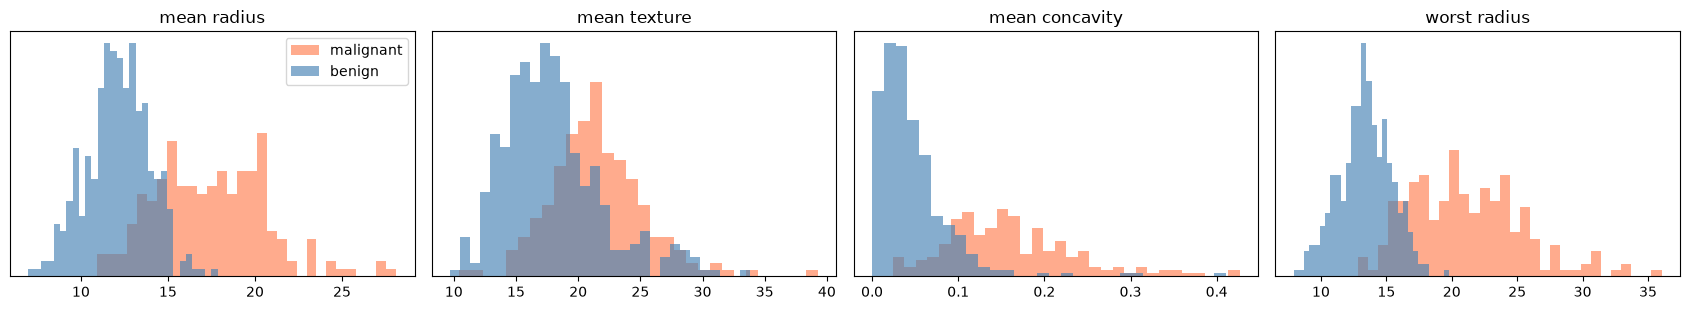

In [7]:
import matplotlib.pyplot as plt

show = ["mean radius", "mean texture", "mean concavity", "worst radius"]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.2))

for ax, name in zip(axes, show):
    col = feat.index(name)
    for cls, colour in [(0, "coral"), (1, "steelblue")]:
        ax.hist(X[y == cls, col], bins=30, alpha=0.65,
                color=colour, label=data.target_names[cls])
    ax.set_title(name)
    ax.set_yticks([])
axes[0].legend()
plt.tight_layout()
plt.show()

## Summary

| | |
|---|---|
| samples | 569 |
| inputs | 30 continuous features (10 measurements x mean / std error / worst) |
| targets | binary, `0 = malignant`, `1 = benign` |
| balance | 212 malignant / 357 benign |
| missing values | none |
| source | bundled with scikit-learn, no download |

Nothing has been split, scaled or modelled here — that is for later.
